# Libraries

In [917]:
import pandas as pd
import numpy as np
import os
import matplotlib.font_manager as fm
import time
import warnings

# Plotting Libs
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree
from xgboost import plot_importance
import shap

# Scaler Libs
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# CV Libs
from sklearn.model_selection import GridSearchCV 
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from sklearn.experimental import enable_halving_search_cv  # must be imported first
from sklearn.model_selection import HalvingGridSearchCV

# Model Libs
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier

# Accuracy Libs
from sklearn.metrics import accuracy_score , classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score

# Resampling Libs
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler


# Load Data

In [918]:
start_time = time.time()

In [919]:
df1 = pd.read_pickle(r".\df_dummies\df1_dummies.pkl")
df2 = pd.read_pickle(r".\df_dummies\df2_dummies.pkl")
df3 = pd.read_pickle(r".\df_dummies\df3_dummies.pkl")
df4 = pd.read_pickle(r".\df_dummies\df4_dummies.pkl")

# Accuracy tests/ Roc Function


In [920]:
def accuracy(dfi, i, model, X_test, y_test, y_pred, title):
    print(f"Model : Phase {i} - {title}")
    
    print("\na).\nBalanced Accuracy Score :")
    acc_bal = f"{balanced_accuracy_score(y_test, y_pred) * 100:.2f}%"
    print(acc_bal)

    print("\nb).\nClassification Report :")
    class_rep = classification_report(y_test, y_pred)
    print(class_rep)

    print("\nc).\nMatthews Correlation Coefficient (MCC) :")
    mcc = f"{matthews_corrcoef(y_test, y_pred):.2f}"
    print(mcc)

    print("\nd).\nPlots :")
    fig , ax = plt.subplots(figsize = (20, 6), nrows = 1, ncols = 3)

    ConfusionMatrixDisplay.from_predictions(y_test , y_pred, ax = ax[0]);
    RocCurveDisplay.from_estimator(model, X_test, y_test, pos_label = 1, ax = ax[1], name = f'{title}');  # Completed = 0, Terminated = 1
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, pos_label=1, ax=ax[2], name=f'{title}')
    
    print(f"ROC AUC : {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]).round(3)}") # Predict Probabilities for accurate ROC Auc")
    print(f"PR AUC : {average_precision_score(y_test, model.predict_proba(X_test)[:, 1]).round(3)}")

    plt.suptitle(f"Phase {i} - {title}", fontsize = 11, fontweight = 'bold')

    # Confusion Matrix
    ax[0].set_title("1. Confusion Matrix", fontsize = 10, fontweight = 'bold')
    ax[0].set_xlabel("Predicted Label", fontsize = 10, fontweight = 'bold')
    ax[0].set_ylabel("True Label", fontsize = 10, fontweight = 'bold')
    
    # Roc Curve
    ax[1].set_title("2. ROC Curve" , fontsize = 10, fontweight = 'bold')
    ax[1].set_ylabel("TPR - Sensitivity - Recall", fontsize = 10, fontweight = 'bold')
    ax[1].set_xlabel("FPR - (1 - Specificity)", fontsize = 10, fontweight = 'bold')

    # PR Cruve
    ax[2].set_title("3. PR Curve", fontsize = 10, fontweight = 'bold')
    ax[2].set_ylabel("PPV - Precision", fontsize = 10, fontweight = 'bold')
    ax[2].set_xlabel("TPR - Sensitivity - Recall", fontsize = 10, fontweight = 'bold')

    plt.show()      
    plt.close(fig)  

    return acc_bal, class_rep, mcc

# SHAP Function
- SHAP Summary PLot:
- Impact on the prediction (how much a feature contributes to pushing the prediction left (negative) or right (positive)).
- Blue = low feature value.
- Red = high feature value.

- Example: Enrollment_Log:
- High values (red) → strong negative SHAP values → push prediction to Completed.
- Low values (blue) → positive SHAP values → push toward Terminated.
- SHAP X-axis shows how much each feature pushes the prediction toward class 0 or 1, in log-odds space. (value -5)

In [921]:
# SHAP dataset overview
def fun_shap(i, model, X_test, model_str):
    X_test_sam = shap.sample(X_test, 100)
    explainer = shap.Explainer(model.predict, X_test_sam)
    shap_values = explainer(X_test_sam)

    # Files/Paths 
    model_str = model_str
    folder_shap = "shap_plots"
    os.makedirs(folder_shap, exist_ok=True)
    filename = f"df{i}_{model_str}_shap_plot.png"
    filepath = os.path.join(folder_shap, filename)

#### Summary Plot SHAP --> Global overview 
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        shap.summary_plot(shap_values, X_test_sam, plot_size=(8, 4), max_display = 15, show=False)
    plt.title(f"df{i} - {model_str} - SHAP Summary Plot", fontsize = 12, fontweight="bold", pad = 15)
    plt.xlabel("SHAP value (impact on model output)", fontsize=12, labelpad=15) 

    ax = plt.gca()
    for label in ax.get_yticklabels()[-6:]:
        label.set_fontweight("bold")
    # Save Summary Plot
    fig = plt.gcf()
    fig.savefig(filepath, dpi = 100, bbox_inches = 'tight')
    plt.show()
    plt.close(fig)

#### Waterfall Plot --> 1 data point prediction --> Local overview
    # plt.figure(figsize = (20, 3), dpi = 100)
    shap.waterfall_plot(shap_values[0], max_display = 10, show = False) 
    plt.title(f"{model_str} SHAP Waterfall Plot", fontsize = 12, fontweight = "bold", pad = 15)
    plt.tight_layout()
    plt.show()

#### SHAP mean values - top features
    shap_value_mean = np.abs(shap_values.values).mean(axis=0).round(3)
    shap_important = pd.DataFrame({
        "Feature": X_test_sam.columns,
        f"df{i}_{model_str}_Shap_Mean" : shap_value_mean
    })
    shap_important = shap_important.sort_values(by = f"df{i}_{model_str}_Shap_Mean", ascending=False).head(6).reset_index(drop=True)
    # Save Mean Shap values
    shap_important.to_pickle(f"./shap_plots/df{i}_{model_str}_mean_shap.pkl")
    display(shap_important)
    
    return shap_important


# Data Preparation

## Df Input

In [922]:
display(df1.shape)
display(df2.shape)
display(df3.shape)
display(df4.shape)

(21829, 84)

(21228, 84)

(13966, 84)

(13246, 84)

In [923]:
i = 1
dfi = df1

## X , y

In [924]:
X = dfi.drop("Study_Status_Bin", axis = 1)
y = dfi["Study_Status_Bin"]

# initial X features
X.shape # Check that initial shape of dfi was not changed.

(21829, 83)

## Train - Test Split

In [925]:
# Train-Test Split
X_train_tts, X_test_tts, y_train_tts, y_test_tts = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

# Imbalanced 0 row = Compeleted, row 1 = terminated
display(f'Terminated/Completed: {y_train_tts.value_counts().iloc[1]/y_train_tts.value_counts().iloc[0]}') 
display(X_train_tts.shape[0], X_test_tts.shape[0])

# EPV
display(y_train_tts[y_train_tts == 1].sum()/(X_train_tts.shape[1]))

'Terminated/Completed: 0.17067775021787224'

17463

4366

30.674698795180724

## Resample
- Datasets are imbalanced towards with the negative class the majority. (i.e. COMPLETED = 0) 
- May induce bias towards majority class. 
- Resample train set only, so model will be correctly trained..
    --> Avoids information leaking to test set. test set always similar to true cases.
- Performance evaluated on unsampled test set, with real data distribution.

In [926]:
res = RandomUnderSampler(sampling_strategy = 'auto', random_state = 42)
X_train_res, y_train_res = res.fit_resample(X_train_tts, y_train_tts) 

# Final train/test ratio
display(f'X_test/X_train : {X_test_tts.shape[0]}/{X_train_res.shape[0]} = {(X_test_tts.shape[0]/X_train_res.shape[0])}')
display(f'X_train_features/X_train_sample : {X_train_res.shape[1]}/{X_train_res.shape[0]} = {(X_train_res.shape[1]/X_train_res.shape[0])}')

'X_test/X_train : 4366/5092 = 0.8574234092694423'

'X_train_features/X_train_sample : 83/5092 = 0.016300078554595445'

## Scaling
- Scale after resample, similarly to train_test_Split so it wont take the skewed distribution of imbalanced data.
- Scaling always after dataset split

In [927]:
def fun_scale(X_train_res, X_test_tts):
    X_train_sc = X_train_res.copy()
    X_test_sc = X_test_tts.copy()

    cont_cols = [col for col in X_train_sc.columns 
                    if (('counts' in col.lower() or 'log' in col.lower()) and
                        not any(x in col.lower() for x in ['bin', 'categ', 'list']))]
    
    scaler = StandardScaler(with_mean = True, with_std = True)
    # scaler = MinMaxScaler()

    X_train_sc[cont_cols] = pd.DataFrame(scaler.fit_transform(X_train_sc[cont_cols]),
        columns = cont_cols, index=X_train_sc.index)

    X_test_sc[cont_cols] = pd.DataFrame(scaler.transform(X_test_sc[cont_cols]),
        columns = cont_cols, index=X_test_sc.index)
    
    return X_train_sc, X_test_sc

X_train_sc, X_test_sc = fun_scale(X_train_res, X_test_tts)

# check if any continues features appear negative values (Negative values are not minigfull to dataset)
col = [col for col in X_train_sc.columns 
                    if (('_Counts' in col or '_Log' in col) and
                        not any(x in col for x in ['_Bin', '_Categ', '_List']))]
X_train_sc[col].describe().round(2)

,Adverse_Counts_Log,Arm_Counts_Log,City_Counts_Log,Enrollment_Counts_Log,"Enrollment_Log_x__Bacterial, Mycoses, Virus Diseases",Enrollment_Log_x__Cardiovascular,"Enrollment_Log_x__Digestive System, Nutritional, Metabolic",Enrollment_Log_x__Endocrine System,Enrollment_Log_x__Eye,"Enrollment_Log_x__Health Care, Therapeutics",...,"Enrollment_Log_x__Musculoskeletal, Neural",Enrollment_Log_x__Neoplasms,Enrollment_Log_x__Nervous System,"Enrollment_Log_x__Pathological Conditions, Signs, Symptoms","Enrollment_Log_x__Phenomena, Processes","Enrollment_Log_x__Psychiatry, Psychology, Anthropology, Sociology","Enrollment_Log_x__Respiratory, Circulatory","Enrollment_Log_x__Skin, Tissue, Wounds","Enrollment_Log_x__Stomatognathic, Otorhinolaryngologic","Enrollment_Log_x__Urogenital, Pregnancy"
count,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,...,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00,5092.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,...,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.39,-1.01,-1.44,-1.91,-0.31,-0.22,-0.39,-0.25,-0.10,-0.09,...,-0.18,-0.63,-0.27,-0.38,-0.15,-0.24,-0.31,-0.33,-0.09,-0.28
25%,-0.39,-1.01,-0.42,-0.54,-0.31,-0.22,-0.39,-0.25,-0.10,-0.09,...,-0.18,-0.63,-0.27,-0.38,-0.15,-0.24,-0.31,-0.33,-0.09,-0.28
50%,-0.39,-0.15,-0.42,0.20,-0.31,-0.22,-0.39,-0.25,-0.10,-0.09,...,-0.18,-0.63,-0.27,-0.38,-0.15,-0.24,-0.31,-0.33,-0.09,-0.28
75%,-0.39,0.47,0.18,0.70,-0.31,-0.22,-0.39,-0.25,-0.10,-0.09,...,-0.18,0.71,-0.27,-0.38,-0.15,-0.24,-0.31,-0.33,-0.09,-0.28
max,6.40,4.82,4.76,3.11,6.04,8.54,4.92,6.57,14.22,14.52,...,10.97,3.83,6.76,4.86,10.36,8.55,6.43,6.46,16.31,6.84


## X_train_X_test

In [928]:
X_train = X_train_sc.copy()
X_test = X_test_sc.copy()
y_train = y_train_res.copy()
y_test = y_test_tts.copy()

## Rename

In [929]:
def fun_rename(X_train, X_test, y_train, y_test):

    X_train.columns = X_train.columns.str.replace(r'List_|Detail_|Adv_Syst_|Adv_', "", regex=True)
    X_train.columns = X_train.columns.str.replace(r'Counts_Log', "Log", regex=True)
    X_train.columns = X_train.columns.str.replace(r'Funder_Type', "Funder", regex=True)
    X_train.columns = X_train.columns.str.replace(r'_', " ", regex=True)

    X_test.columns = X_test.columns.str.replace(r'List_|Detail_|Adv_Syst_|Adv_', "", regex=True)
    X_test.columns = X_test.columns.str.replace(r'Counts_Log', "Log", regex=True)
    X_test.columns = X_test.columns.str.replace(r'Funder_Type', "Funder", regex=True)
    X_test.columns = X_test.columns.str.replace(r'_', " ", regex=True)

    y_train.name = y_train.name.replace('Study_Status_Bin', 'Study Status')
    y_test.name = y_test.name.replace('Study_Status_Bin', 'Study Status')

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = fun_rename(X_train, X_test, y_train, y_test)

# X_train.columns.to_list()

# Models

## A) Classic Classification

### Logistic (L1)

Model : Phase 1 - Lasso Logistic Regression (L1)

a).
Balanced Accuracy Score :
78.58%

b).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      3729
           1       0.41      0.76      0.53       637

    accuracy                           0.80      4366
   macro avg       0.68      0.79      0.70      4366
weighted avg       0.87      0.80      0.83      4366


c).
Matthews Correlation Coefficient (MCC) :
0.45

d).
Plots :
ROC AUC : 0.874
PR AUC : 0.683


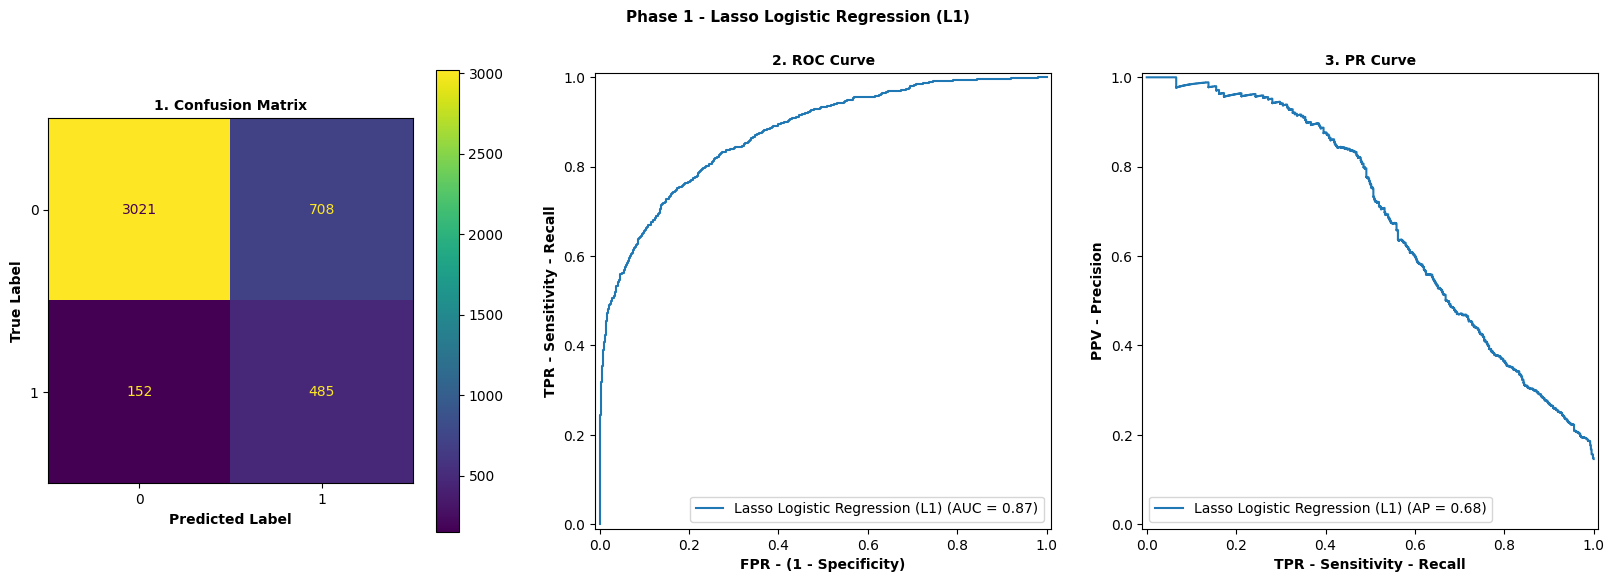

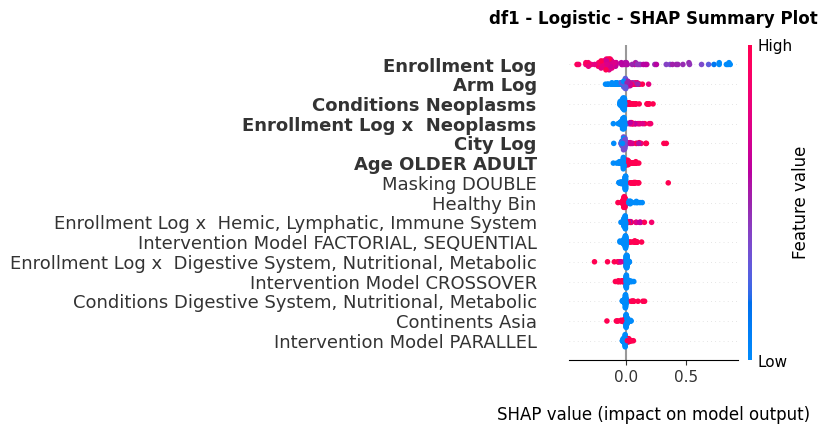

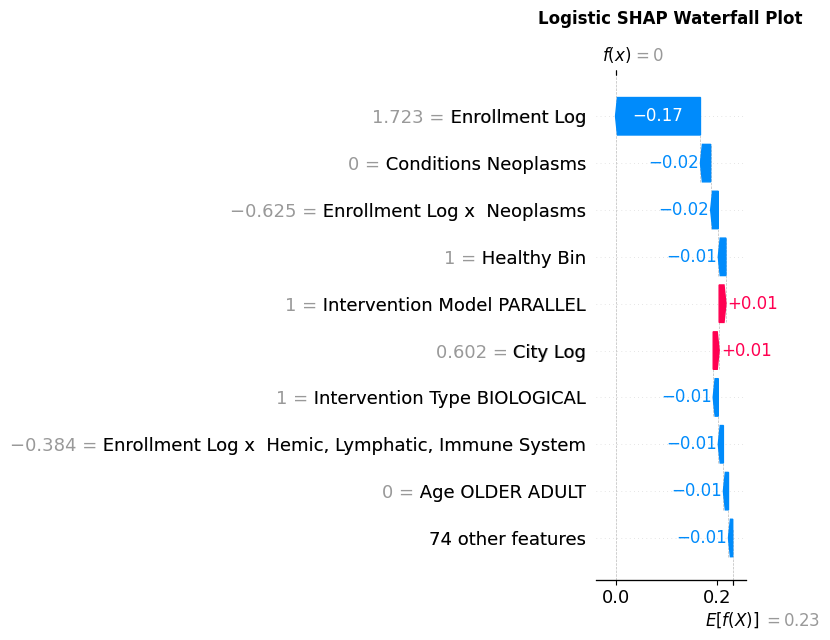

,Feature,df1_Logistic_Shap_Mean
0,Enrollment Log,0.237
1,Arm Log,0.043
2,Conditions Neoplasms,0.038
3,Enrollment Log x Neoplasms,0.038
4,City Log,0.033
5,Age OLDER ADULT,0.028


In [930]:
# Model
log_reg = LogisticRegression(penalty = 'l1', max_iter = 5000 , solver = 'saga', class_weight = 'balanced',  random_state = 42)  

# Final Model
log_model = log_reg.fit(X_train, y_train)

# y_pred
y_pred_log_l1 = log_model.predict(X_test)

# Accuracy Score
acc_log, class_log, mcc_log = accuracy(dfi, i, log_model, X_test, y_test, y_pred_log_l1, "Lasso Logistic Regression (L1)")

log_shap = fun_shap(i, log_model, X_test, 'Logistic')


### LDA - Linear Discriminant Analysis

- QDA and LDA assume Gaussian distributions.

Best Parameters : {'n_components': 1, 'shrinkage': 0.12}
Best Estimator : LinearDiscriminantAnalysis(n_components=1, shrinkage=0.12, solver='lsqr',
                           store_covariance=True)
Model : Phase 1 - Linear Discriminant Analysis (LDA)

a).
Balanced Accuracy Score :
78.63%

b).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      3729
           1       0.41      0.76      0.53       637

    accuracy                           0.80      4366
   macro avg       0.68      0.79      0.70      4366
weighted avg       0.87      0.80      0.83      4366


c).
Matthews Correlation Coefficient (MCC) :
0.45

d).
Plots :
ROC AUC : 0.874
PR AUC : 0.68


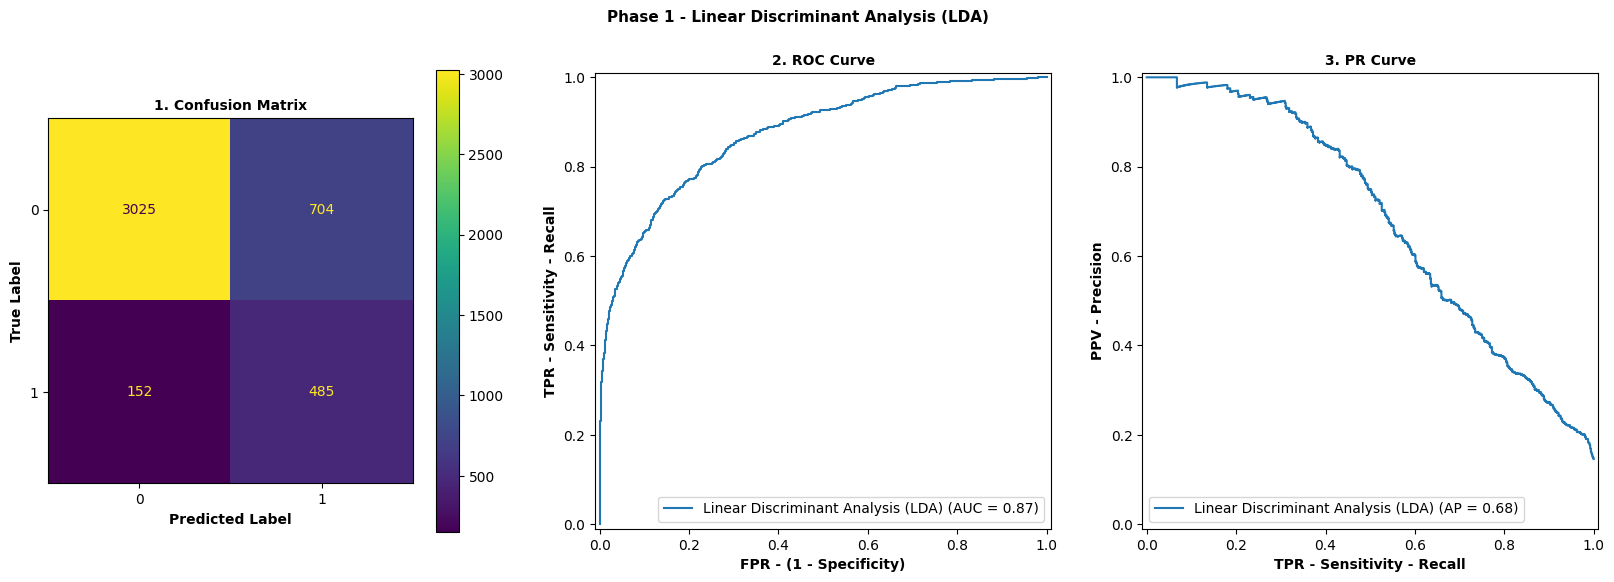

In [931]:
# Model
lda = LDA(store_covariance = True, solver = 'lsqr') # Use solver = lsqr if cv needed.

# HPO
param_grid = {
    "shrinkage" : [None, "auto"] + list(np.linspace(0.01, 1.0, 10)), # sklearn doc: float between 0 and 1
    'n_components' : np.arange(1, min(X_train.shape[1], len(np.unique(y_train)) - 1) + 1)
    } 
# CV
grid = HalvingGridSearchCV(estimator = lda, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1) 

# Final Model
lda_model = grid.fit(X_train, y_train) # automatically gives the best.estimator
print(f'Best Parameters : {lda_model.best_params_}')
print(f'Best Estimator : {lda_model.best_estimator_}')

# y_pred
y_pred_lda = lda_model.predict(X_test)

# Accuracy Score
acc_lda, class_lda, mcc_lda = accuracy(dfi, i, lda_model, X_test, y_test, y_pred_lda, "Linear Discriminant Analysis (LDA)")

# SHAP
# lda_shap = fun_shap(i, lda_model, X_test, 'LDA')

### QDA - Quantratic Discriminant Analysis
- QDA very sensistive to collinear data!
QDA and LDA assume Gaussian distributions.

"Best Parameters : {'reg_param': 0.5172413793103449}"

'Best Estimator : QuadraticDiscriminantAnalysis(reg_param=0.5172413793103449,\n                              store_covariance=True)'

Model : Phase 1 - Quantric Discriminant Analysis (QDA)

a).
Balanced Accuracy Score :
71.07%

b).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.59      0.73      3729
           1       0.26      0.83      0.39       637

    accuracy                           0.62      4366
   macro avg       0.61      0.71      0.56      4366
weighted avg       0.85      0.62      0.68      4366


c).
Matthews Correlation Coefficient (MCC) :
0.30

d).
Plots :
ROC AUC : 0.826
PR AUC : 0.588


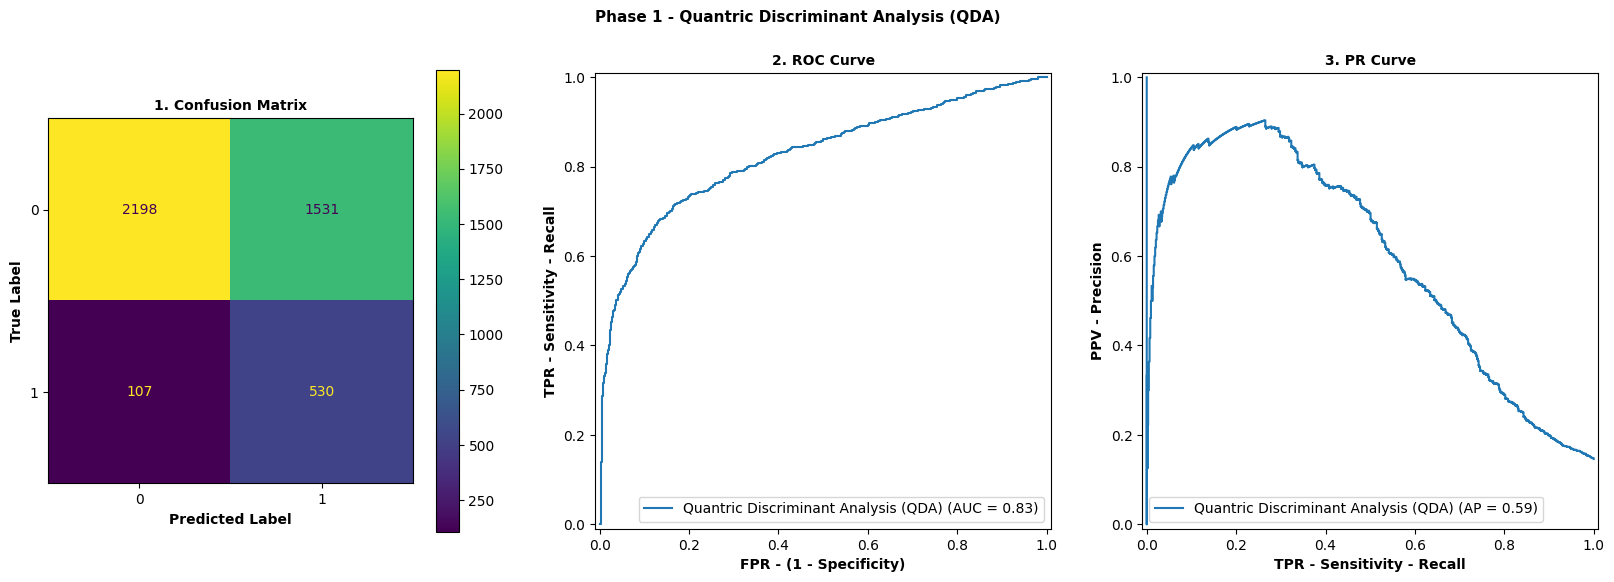

In [932]:
# Model
# QDA does not assume linear relation X - y --> lasso assumes. 
qda = QDA(store_covariance = True)

# HPO
param_grid = {
    "reg_param": np.linspace(0, 1, 30) # value range [0,1]
    }

# CV
grid = HalvingGridSearchCV(estimator = qda, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1) # cv = 5 default # n_jobs = -1 avoid overload

# Final model
qda_model = grid.fit(X_train, y_train)
display(f'Best Parameters : {qda_model.best_params_}')
display(f'Best Estimator : {qda_model.best_estimator_}')

# y_pred
y_pred_qda = qda_model.predict(X_test)

# Accuracy Score
acc_qda, class_qda, mcc_qda = accuracy(dfi, i, qda_model, X_test, y_test, y_pred_qda, "Quantric Discriminant Analysis (QDA)")

# SHAP
# qda_shap = fun_shap(i, qda_model, X_test, 'QDA')


### Elastic Net Logistic Regression
- l1_ratio l1 / l2 = Elastic Net
- l1_ratio = 1 = Lasso (l1)
- l1_ratio = 0 = Ridge (l2) 
- 0 < l1_ratio < 1 

In [933]:
# Model (4+min df5)
log_el = LogisticRegression(penalty = 'elasticnet', max_iter = 3000, solver = "saga", random_state = 42)   

# HPO
param_grid = {
    'C': [0.01, 1, 10, 100, 1000],
    "l1_ratio" : np.linspace(0.01, 1, 10, endpoint = True)
    } 
# CV
grid = HalvingGridSearchCV(estimator = log_el, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
el_model = grid.fit(X_train, y_train)  
display(f'Best Parameters : {el_model.best_params_}')
display(f'Best Estimator : {el_model.best_estimator_}')

# y_pred
y_pred_el = el_model.predict(X_test)

# Accuracy Score
acc_el, class_el, mcc_el = accuracy(dfi, i, el_model, X_test, y_test, y_pred_el, "Elastic Net Logistic Regression")

# SHAP
# el_shap = fun_shap(i, el_model, X_test, 'Elastic_Net')


KeyboardInterrupt: 

## B) ML Classification

### KNN - K Nearest Neighbors

"Best Parameters : {'n_neighbors': 20}"

'Best Estimator : KNeighborsClassifier(n_neighbors=20)'

Model : Phase 1 - K-Nearest Neighbors Classifier (KNN)

a).
Balanced Accuracy Score :
76.91%

b).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      5594
           1       0.40      0.73      0.51       955

    accuracy                           0.80      6549
   macro avg       0.67      0.77      0.69      6549
weighted avg       0.87      0.80      0.82      6549


c).
Matthews Correlation Coefficient (MCC) :
0.43

d).
Plots :
ROC AUC : 0.836
PR AUC : 0.597


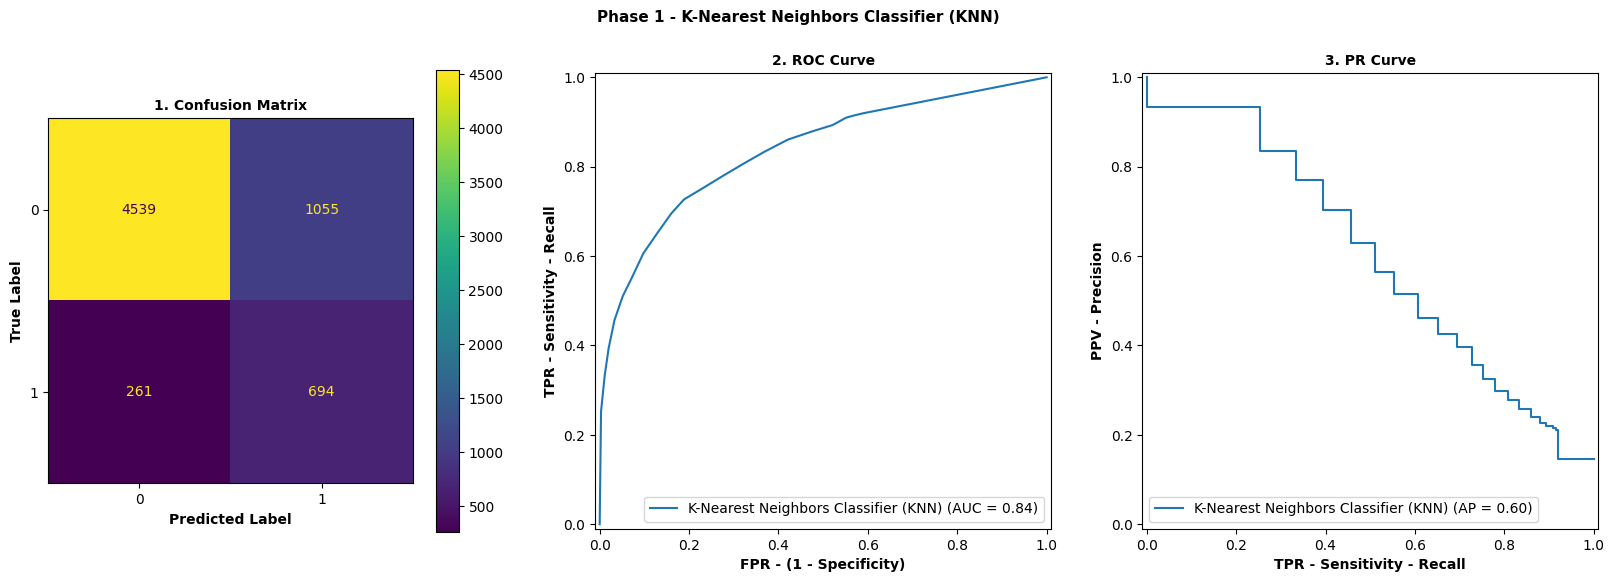

In [ ]:
# Model 
knn = KNeighborsClassifier()

# HPO 
param_grid = {
    "n_neighbors" : np.linspace(5, 100, 30, endpoint = True).astype(int)
    } 

# CV
grid = HalvingGridSearchCV(estimator = knn , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
knn_model = grid.fit(X_train, y_train)
display(f'Best Parameters : {knn_model.best_params_}')
display(f'Best Estimator : {knn_model.best_estimator_}')

# y_pred
y_pred_knn = knn_model.predict(X_test)

# Accuracy Score
acc_knn, class_knn, mcc_knn = accuracy(dfi, i, knn_model, X_test, y_test, y_pred_knn, "K-Nearest Neighbors Classifier (KNN)")

# SHAP
# knn_shap = fun_shap(i, knn_model, X_test, 'KNN')

### SVC - Support Vector Classifier
- Always Chooses rbf
- poly is not going to be checked as it extremely increases compuational time, wihtout never be chosen. 
- rbf can find some non-linear boundries close to poly if needed. 


In [ ]:
# Model
svc = SVC(probability = True, random_state = 42, class_weight = 'balanced', kernel = 'rbf')
 
# HPO
param_grid = {"C": [0.5, 1, 1.5, 2], 
              'gamma': ['scale','auto']
              }
# CV
grid = HalvingGridSearchCV(estimator = svc, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1,)

# Final Model
svc_model = grid.fit(X_train, y_train)
display(f'Best Parameter: {svc_model.best_params_}')
display(f'Best Estimator: {svc_model.best_estimator_}')

# y_pred
y_pred_svc = svc_model.predict(X_test)

# Accuracy Score
acc_svc, class_svc, mcc_svc = accuracy(dfi, i, svc_model, X_test, y_test, y_pred_svc, "Support Vector Classifier (SVC)")

# SHAP
svc_shap = fun_shap(i, svc_model, X_test, 'SVC') # Hide for computational efficacy

KeyboardInterrupt: 

### Tree (Pruned)


In [ ]:
# cc_alphas values meaningful for dataset
tree = DecisionTreeClassifier(random_state = 42)
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
display(ccp_alphas.min(), ccp_alphas.mean(), ccp_alphas.max())

0.0

0.0008215291866829099

0.1279214995350656

"Best Parameter criterion/max_depth: {'ccp_alpha': 0.028426999896681245, 'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}"

"Best Estimator : DecisionTreeClassifier(ccp_alpha=0.028426999896681245, class_weight='balanced',\n                       max_depth=4, min_samples_leaf=4, min_samples_split=10,\n                       random_state=42)"

Model : Phase 1 - Decision Tree Classifier

a).
Balanced Accuracy Score :
76.76%

b).
Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      3729
           1       0.34      0.80      0.48       637

    accuracy                           0.74      4366
   macro avg       0.65      0.77      0.65      4366
weighted avg       0.87      0.74      0.78      4366


c).
Matthews Correlation Coefficient (MCC) :
0.40

d).
Plots :
ROC AUC : 0.81
PR AUC : 0.416


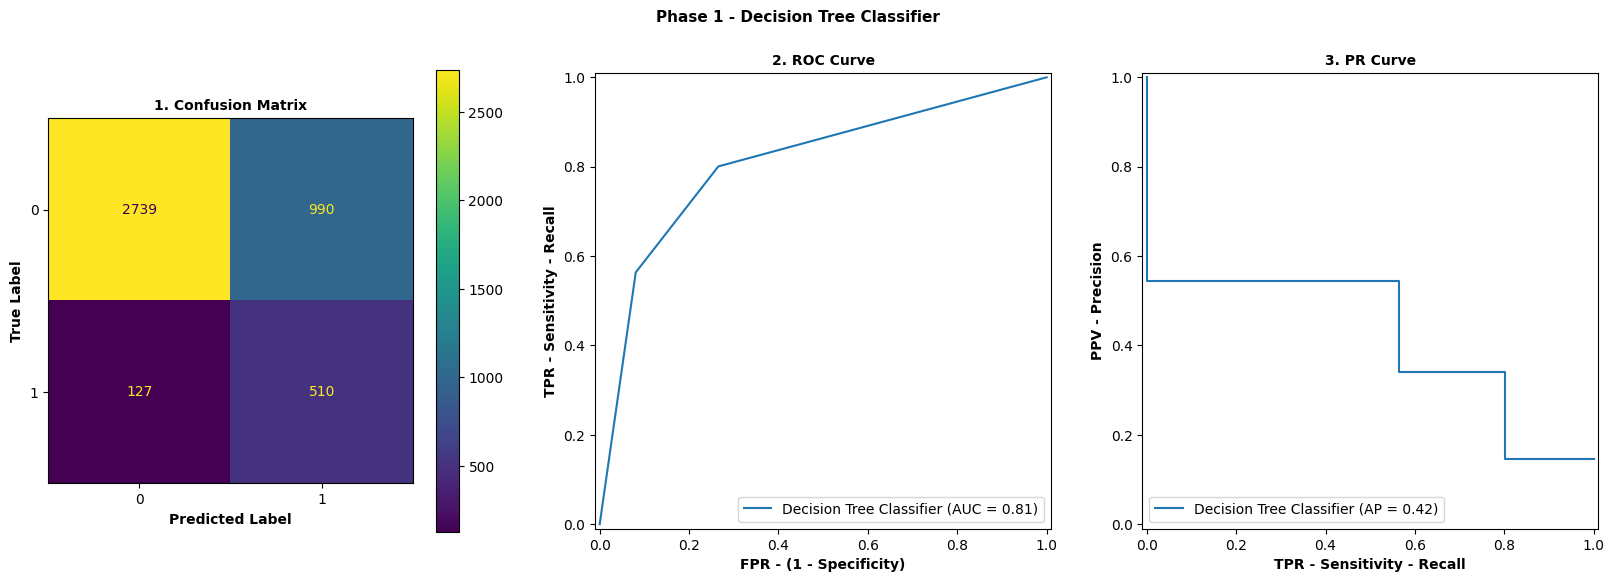

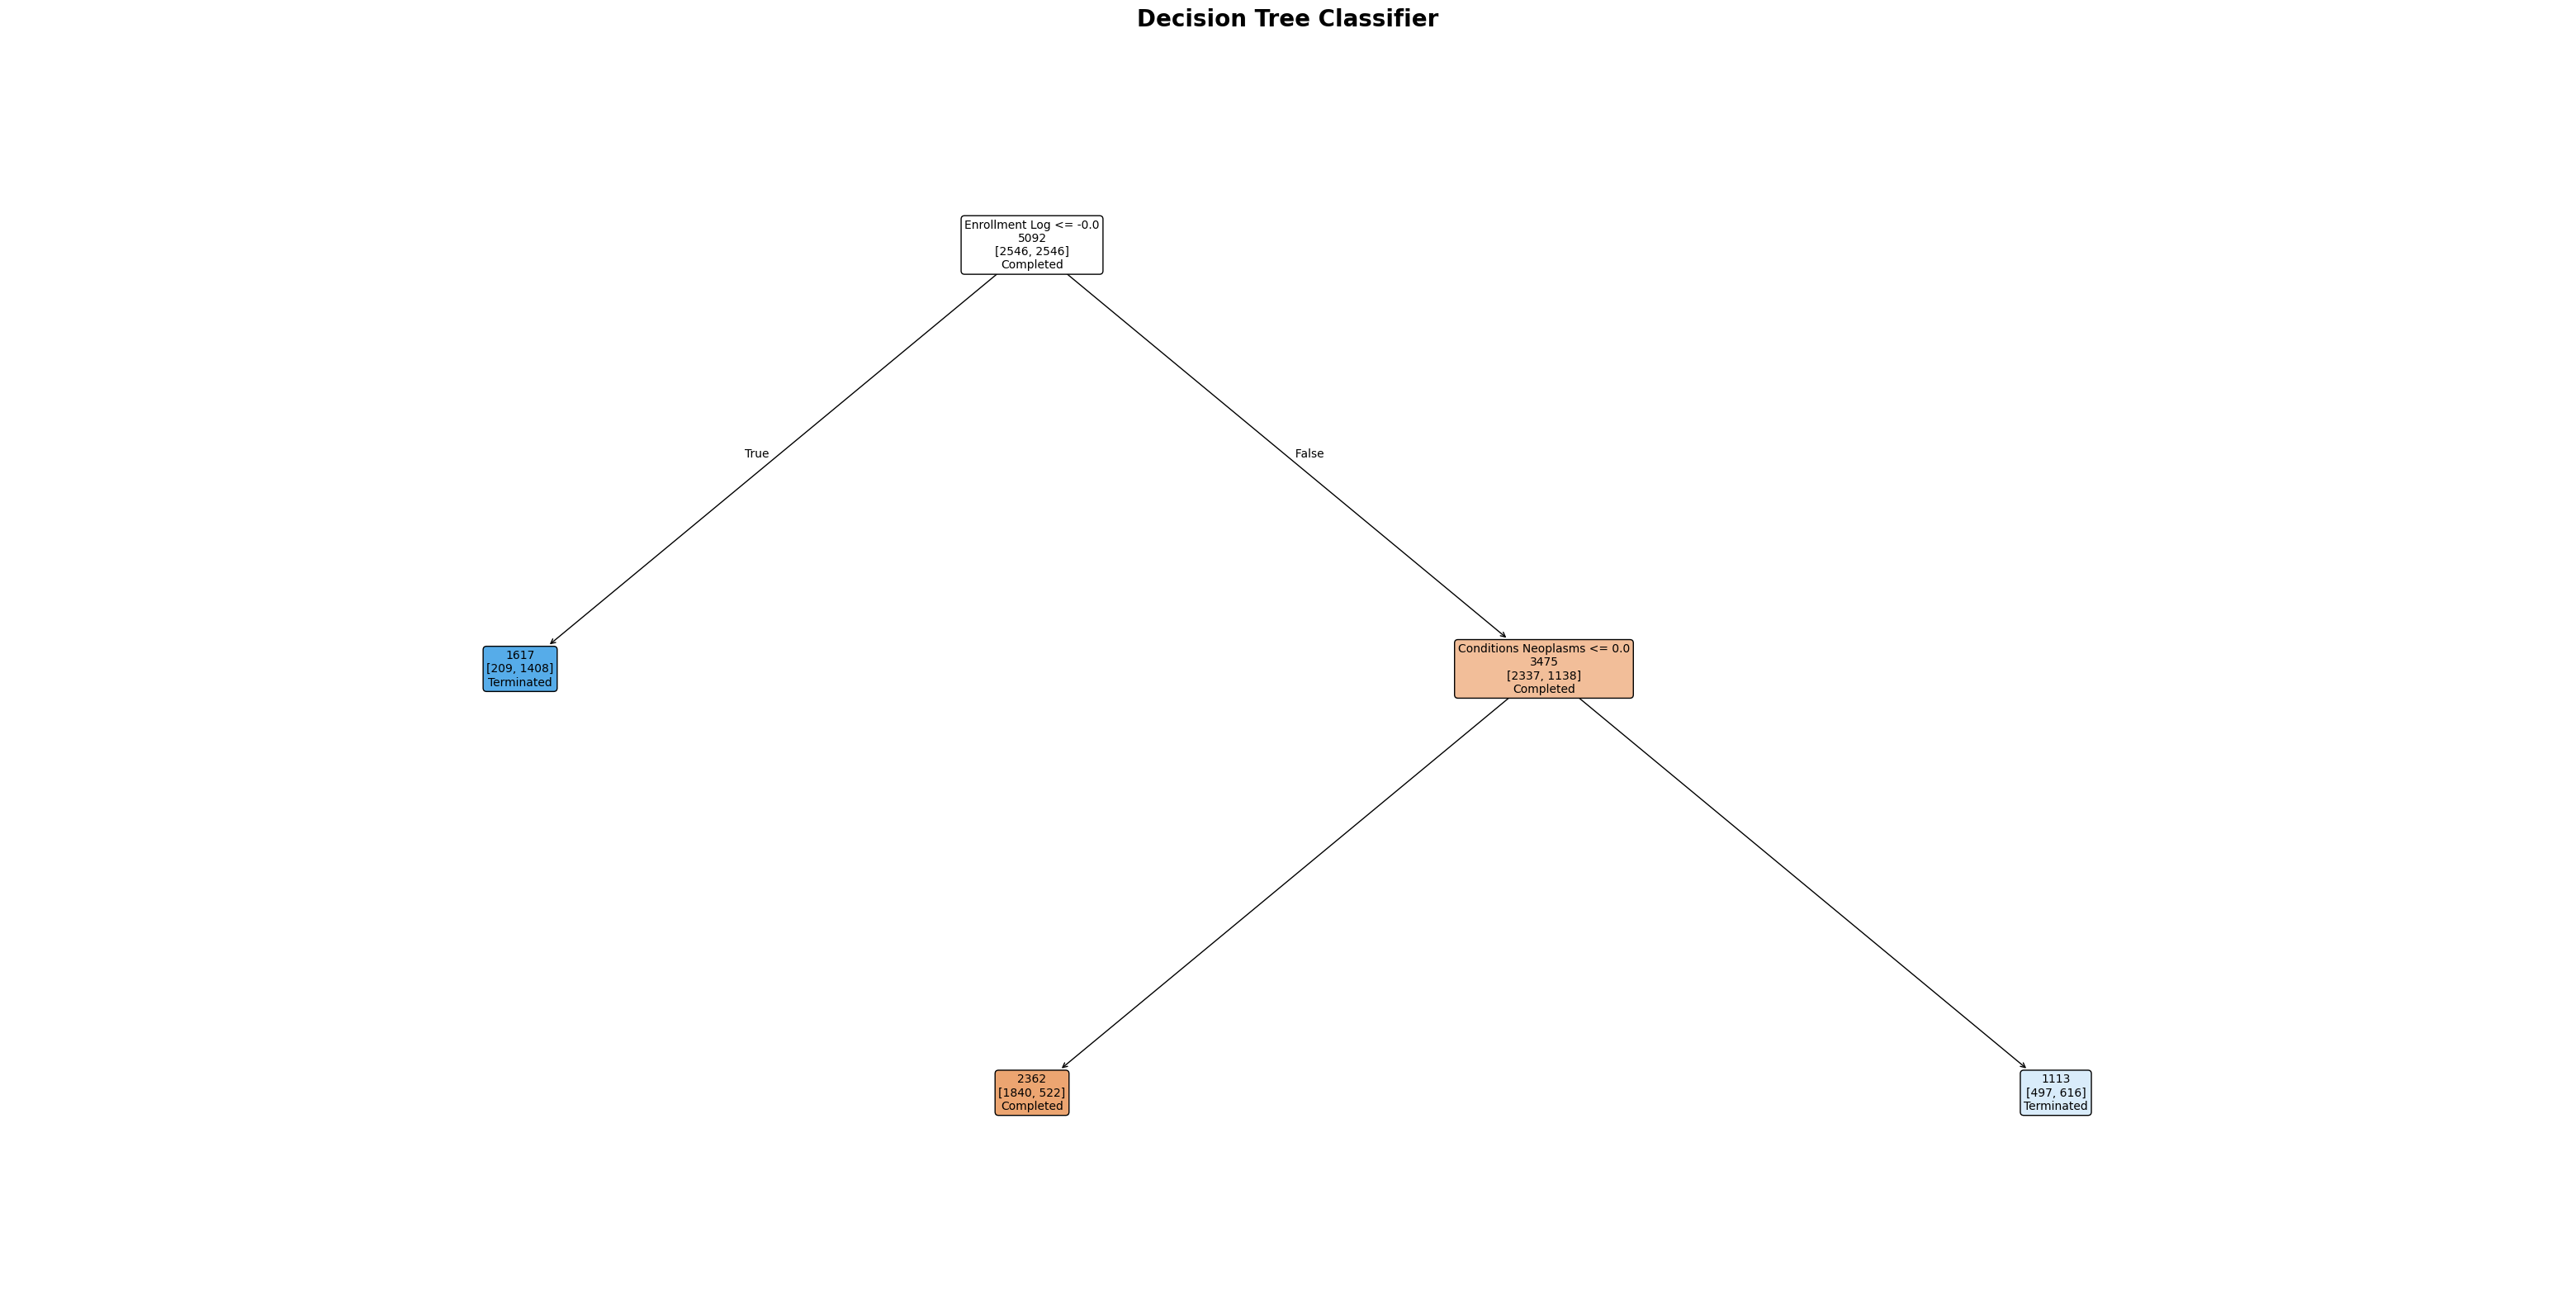

In [ ]:
# Model 
tree = DecisionTreeClassifier(random_state = 42, class_weight = "balanced")

# Hyperparameters CV
param_grid = {
    'criterion': ['gini', 'entropy'],           # Splitting strategy
    'max_depth': [2, 3, 4, 5, 6, 7, None],      # give small depth as choice # Pre-pruning --> Built in feature Selection
    'min_samples_split': [2, 5, 10],            # Min samples to split a node
    'min_samples_leaf': [1, 2, 4],              # Min samples in a leaf
    'max_features': [None, 'sqrt', 'log2'],     # Max features to consider at each split
    'ccp_alpha': np.linspace(0, np.max(ccp_alphas), 10),   # Post-Pruning --> Cost-complexity parameter
}

# CV
grid = HalvingGridSearchCV(estimator = tree, param_grid = param_grid, cv = 5, n_jobs = -1)

# Final Model
tr_model = grid.fit(X_train, y_train)
display(f'Best Parameter criterion/max_depth: {tr_model.best_params_}')
display(f'Best Estimator : {tr_model.best_estimator_}')

# y_pred
y_pred_tr = tr_model.predict(X_test)

# Accuracy Score
acc_tr, class_tr, mcc_tr = accuracy(dfi, i, tr_model, X_test, y_test, y_pred_tr, "Decision Tree Classifier")

# Plot Tree
tree_clf = tr_model.best_estimator_

plt.figure(figsize = (40, 20))
plot_tree(
    tree_clf,
    feature_names = X_train.columns,
    class_names = ['Completed', 'Terminated'],
    max_depth = tr_model.best_params_['max_depth'],
    label = 'none',
    filled = True,
    rounded = True,
    proportion = False,
    impurity = False,
    precision = 0,
    fontsize = 10
)
plt.title("Decision Tree Classifier", fontsize = 20, fontweight = 'bold')
plt.show()

# SHAP
# tr_shap = fun_shap(i, tr_model, X_test, 'Tree')

### Random Forest

"Best Parameter criterion/bootstrap/n_estimators : {'bootstrap': True, 'criterion': 'log_loss', 'max_features': 'sqrt'}"

"Best Estimator : RandomForestClassifier(class_weight='balanced', criterion='log_loss',\n                       random_state=42)"

Model : Phase 1 - Random Forest Classifier

a).
Balanced Accuracy Score :
79.33%

b).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      3729
           1       0.45      0.74      0.56       637

    accuracy                           0.83      4366
   macro avg       0.70      0.79      0.73      4366
weighted avg       0.88      0.83      0.84      4366


c).
Matthews Correlation Coefficient (MCC) :
0.48

d).
Plots :
ROC AUC : 0.875
PR AUC : 0.672


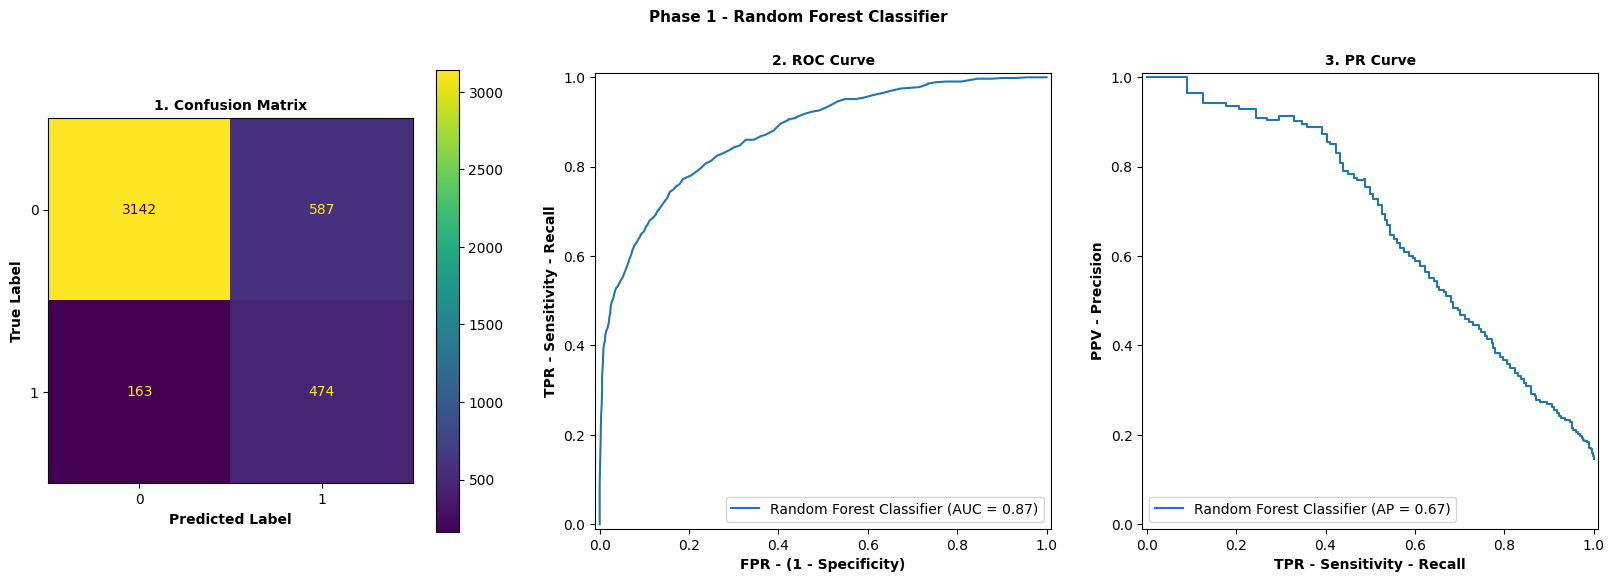

In [ ]:
# Model 
forest = RandomForestClassifier(random_state = 42, class_weight = 'balanced')

# CV
param_grid = {
    "criterion" : ['gini', 'entropy', 'log_loss'], 
    "bootstrap" : [True, False],  # Bootstrap samples when building trees. If False, the whole dataset is used to build each tree.
    "max_features" : ["sqrt", "log2", None],  # None = m = p = Bagging Random Forest. / sqrt = m = sqrt(p) = Classic Random Forest. / log2 = m = log2(p) = Other Random Forest.
}

grid = HalvingGridSearchCV(estimator = forest , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
rf_model = grid.fit(X_train, y_train)
display(f'Best Parameter criterion/bootstrap/n_estimators : {rf_model.best_params_}')
display(f'Best Estimator : {rf_model.best_estimator_}')

# y_pred
y_pred_rf = rf_model.predict(X_test)

# Accuracy Score
acc_rf, class_rf, mcc_rf = accuracy(dfi, i, rf_model, X_test, y_test, y_pred_rf, "Random Forest Classifier")

# SHAP
rf_shap = fun_shap(i, rf_model, X_test, 'Random_Forest')

### Gradient Boosting Classifier

"Best Parameter learning_rate : {'learning_rate': 0.05, 'max_depth': 3}"

'Best Estimator : GradientBoostingClassifier(learning_rate=0.05, random_state=42)'

Model : Phase 1 - Gradient Boosting Classifier

a).
Balanced Accuracy Score :
79.49%

b).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      3729
           1       0.44      0.75      0.56       637

    accuracy                           0.83      4366
   macro avg       0.70      0.79      0.72      4366
weighted avg       0.88      0.83      0.84      4366


c).
Matthews Correlation Coefficient (MCC) :
0.48

d).
Plots :
ROC AUC : 0.884
PR AUC : 0.709


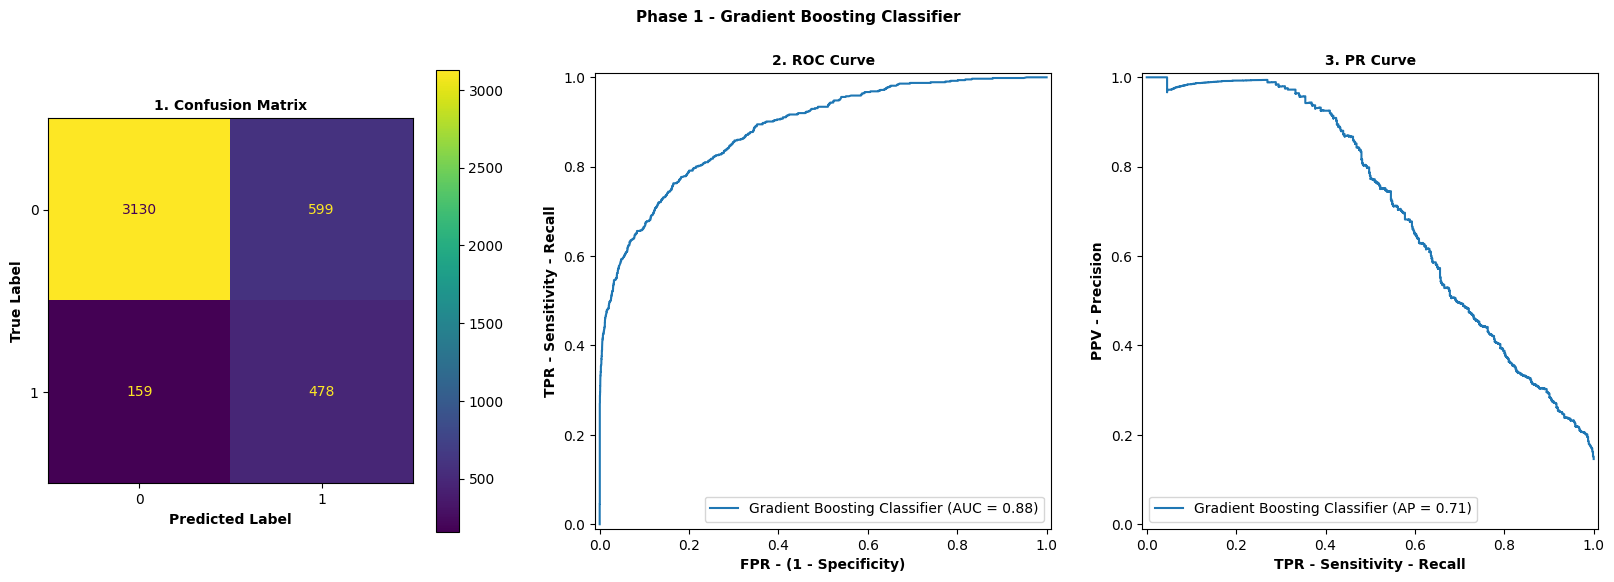

In [ ]:
# Model (+10 mins)
gra_boost = GradientBoostingClassifier(random_state = 42)  

# CV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    }

grid = HalvingGridSearchCV(estimator = gra_boost , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
gb_model = grid.fit(X_train, y_train)
display(f'Best Parameter learning_rate : {gb_model.best_params_}')
display(f'Best Estimator : {gb_model.best_estimator_}')

# y_pred
y_pred_gb = gb_model.predict(X_test)

# Accuracy Score
acc_gb, class_gb, mcc_gb = accuracy(dfi, i, gb_model, X_test, y_test, y_pred_gb, "Gradient Boosting Classifier")

# SHAP
gb_shap = fun_shap(i, gb_model, X_test, 'GBoost')

### Extreme Gradient Boost

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3}
Model : Phase 1 - XGBoosting Classifier

a).
Balanced Accuracy Score :
79.90%

b).
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      3729
           1       0.45      0.75      0.57       637

    accuracy                           0.83      4366
   macro avg       0.70      0.80      0.73      4366
weighted avg       0.88      0.83      0.85      4366


c).
Matthews Correlation Coefficient (MCC) :
0.49

d).
Plots :
ROC AUC : 0.885
PR AUC : 0.714


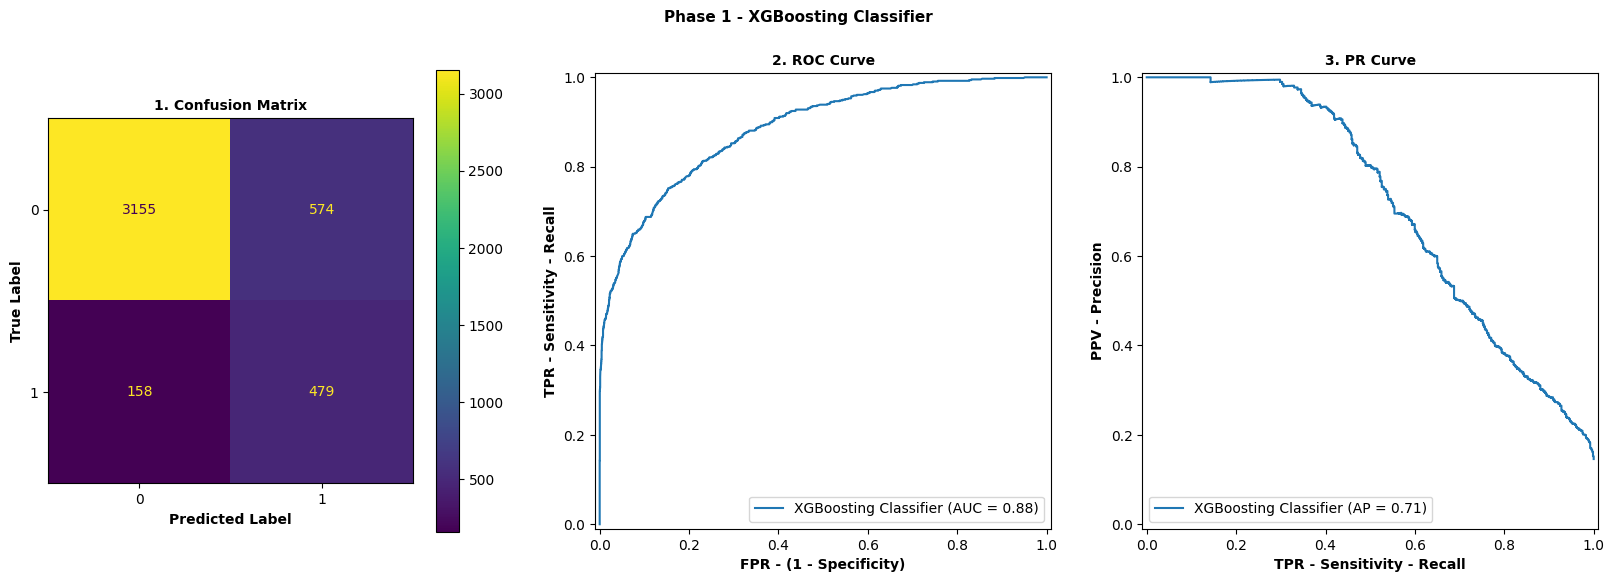

In [ ]:
# Model
xgb = XGBClassifier(objective = 'binary:logistic', eval_metric = 'logloss', random_state = 42) 
# Doc: For classification, ‘log_loss’.

# CV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'colsample_bytree': [0.5, 0.7, 1.0]
    }

grid = HalvingGridSearchCV(estimator = xgb, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
xgb_model = grid.fit(X_train, y_train)
print("Best Parameters:", xgb_model.best_params_)
# print("Best Estimator:", xgb_model.best_estimator_) # too long output. 

# y_pred
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy Score
acc_xgb, class_xgb, mcc_xgb = accuracy(dfi, i, xgb_model, X_test, y_test, y_pred_xgb, "XGBoosting Classifier")

# SHAP
xgb_shap = fun_shap(i, xgb_model, X_test, 'XGBoost')

# ROC Curve

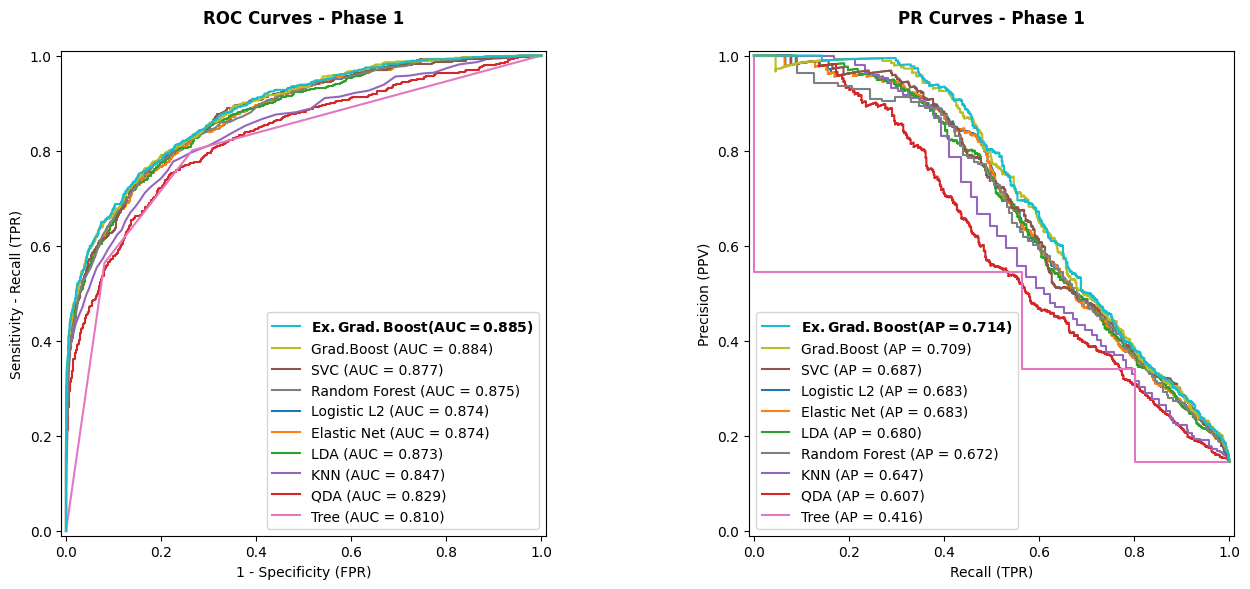

In [ ]:
# Save Path
folder_roc = "roc_plots"
os.makedirs(folder_roc, exist_ok=True)
filename = f"roc_df{i}.png"
filepath = os.path.join(folder_roc, filename)

# Models
models = [
    ("Logistic L2", log_model, X_test, y_test),
    ("Elastic Net", el_model, X_test, y_test),
    ("LDA", lda_model, X_test, y_test),
    ("QDA", qda_model, X_test, y_test),
    ("KNN", knn_model, X_test, y_test),
    ("SVC", svc_model, X_test, y_test),
    ("Tree", tr_model, X_test, y_test),
    ("Random Forest", rf_model, X_test, y_test),
    ("Grad.Boost", gb_model, X_test, y_test),
    ("Ex.Grad.Boost", xgb_model, X_test, y_test)
]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

roc_aucs = []
pr_aucs = []

for original_name, model, X_test_model, y_test_model in models:
    y_score = model.predict_proba(X_test_model)[:, 1]  

# ROC Curve
    auc = roc_auc_score(y_test_model, y_score)
    label_roc = f"{original_name} (AUC = {auc:.3f})"
    roc = RocCurveDisplay.from_estimator(
        model, X_test_model, y_test_model, ax=ax_roc,
        name=label_roc, pos_label = 1  # Completed = 0, Terminated = 1
    )
    roc_aucs.append((auc, label_roc, roc.line_))

# PR Curve
    ap = average_precision_score(y_test_model, y_score)
    label_pr = f"{original_name} (AP = {ap:.3f})"
    pr = PrecisionRecallDisplay.from_estimator(
        model, X_test_model, y_test_model, ax=ax_pr,
        name=label_pr, pos_label=1
    )
    pr_aucs.append((ap, label_pr, pr.line_))

# Sort models at legends
roc_aucs.sort(key=lambda x: x[0], reverse=True)
pr_aucs.sort(key=lambda x: x[0], reverse=True)

# Bold best model
roc_handles = [item[2] for item in roc_aucs]
roc_labels = [f"$\\bf{{{item[1]}}}$" if i == 0 else item[1] for i, item in enumerate(roc_aucs)]
ax_roc.legend(roc_handles, roc_labels, loc = "lower right")

pr_handles = [item[2] for item in pr_aucs]
pr_labels = [f"$\\bf{{{item[1]}}}$" if i == 0 else item[1] for i, item in enumerate(pr_aucs)]
ax_pr.legend(pr_handles, pr_labels, loc = "lower left")

# Titles/ labels
ax_roc.set_title(f"ROC Curves - Phase {i}", fontsize = 12, fontweight = 'bold', pad = 20)
ax_roc.set_ylabel("Sensitivity - Recall (TPR)", fontsize = 10)
ax_roc.set_xlabel("1 - Specificity (FPR)", fontsize = 10)

ax_pr.set_title(f"PR Curves - Phase {i}", fontsize = 12, fontweight = 'bold', pad = 20)
ax_pr.set_ylabel("Precision (PPV)", fontsize = 10)
ax_pr.set_xlabel("Recall (TPR)", fontsize = 10)

plt.tight_layout()

# Save Plot
plt.savefig(filepath, dpi=100, bbox_inches="tight")
plt.show()
plt.close()

# MCCs
= MCC [-1, 1]
- MCC = 0 = Random Guessing 

In [ ]:
MCC = pd.DataFrame({
        'Models': ['Logistic', 'LDA', 'QDA', 'Elastic_Net', 'KNN', 'SVC', 'Tree', 'Random_Forest', 'Grad_Boost', 'Ex_Grad_Boost'],\
        'MCC': [mcc_log, mcc_lda, mcc_qda, mcc_el, mcc_knn, mcc_svc, mcc_tr, mcc_rf, mcc_gb, mcc_xgb]
                })

MCC

,Models,MCC
0,Logistic,0.45
1,LDA,0.45
2,QDA,0.37
3,Elastic_Net,0.45
4,KNN,0.44
5,SVC,0.48
6,Tree,0.40
7,Random_Forest,0.48
8,Grad_Boost,0.48
9,Ex_Grad_Boost,0.49


# Save Metrics

In [ ]:
MCC.to_pickle(f"./shap_plots/df{i}_mcc.pkl")

# Time

In [ ]:
end_time = time.time()
elapsed_minutes = (end_time - start_time) / 60
print(f"Execution time: {elapsed_minutes:.0f} minutes")

Execution time: 3 minutes
